### 1)Store processed data in a new CSV file without using built-in DataFrame export functions, manually formatting and writing the data while ensuring optimal storage efficiency.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("heart_disease.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (25, 14)

Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [3]:
processed_df = df.copy()

processed_df = processed_df.drop_duplicates()

processed_df = processed_df.fillna(processed_df.median(numeric_only=True))

print("Original Shape:", df.shape)
print("Processed Shape:", processed_df.shape)

Original Shape: (25, 14)
Processed Shape: (25, 14)


In [4]:
output_file = "processed_heart_disease.csv"

with open(output_file, "w", encoding="utf-8", newline="") as file:

    headers = processed_df.columns.tolist()
    file.write(",".join(headers) + "\n")

    for row in processed_df.itertuples(index=False, name=None):
        values = []

        for value in row:
            if pd.isna(value):
                values.append("")
            else:
                values.append(str(value))

        file.write(",".join(values) + "\n")

print("File created:", output_file)

File created: processed_heart_disease.csv


In [5]:
new_df = pd.read_csv("processed_heart_disease.csv")

print("New File Shape:", new_df.shape)
new_df.head()

New File Shape: (25, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### 2)Create histograms for all numerical features without using built-in plotting functions, implementing binning and frequency calculations manually.

In [6]:
numeric_columns = processed_df.select_dtypes(
    include=np.number
).columns

print("Numerical Features:")
print(numeric_columns.tolist())

Numerical Features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


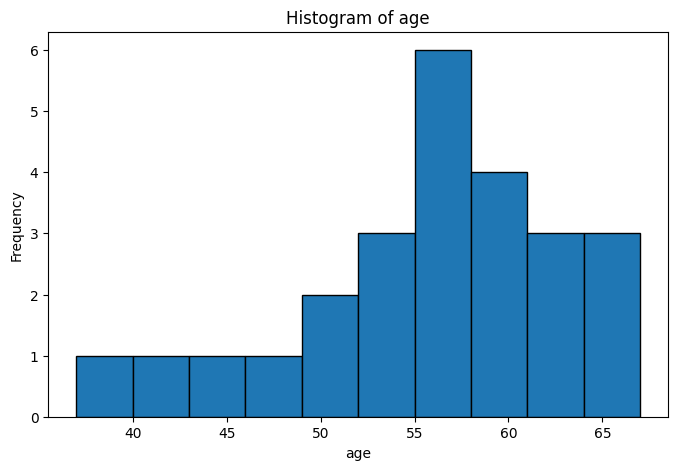

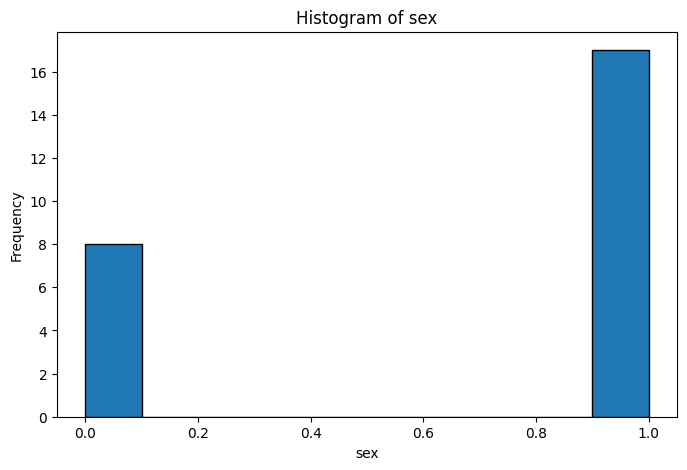

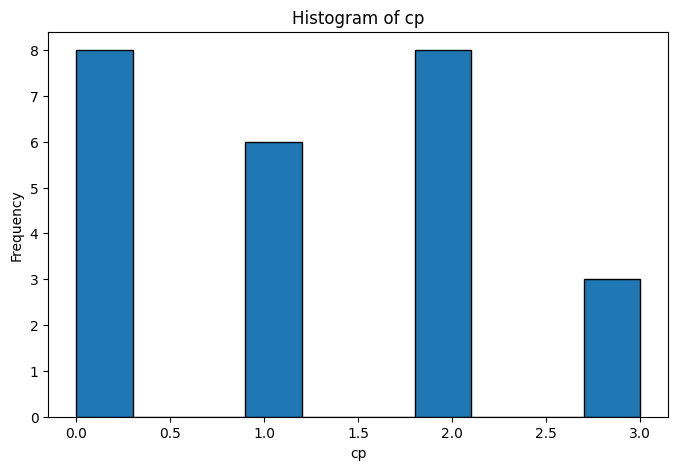

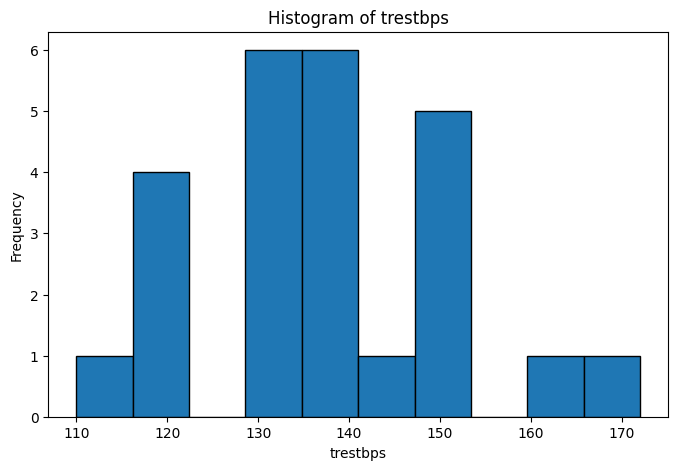

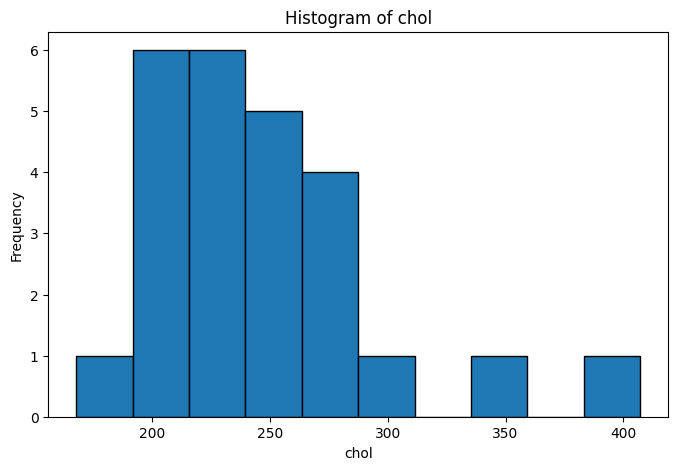

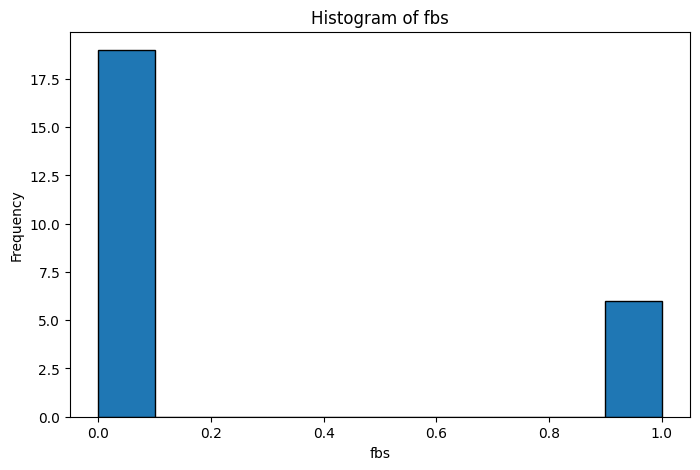

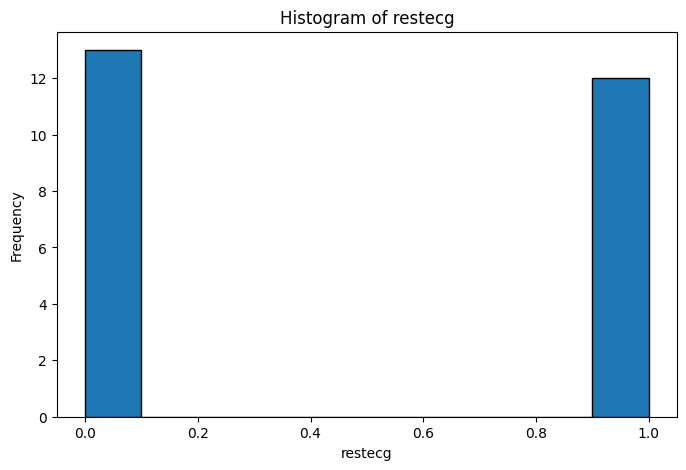

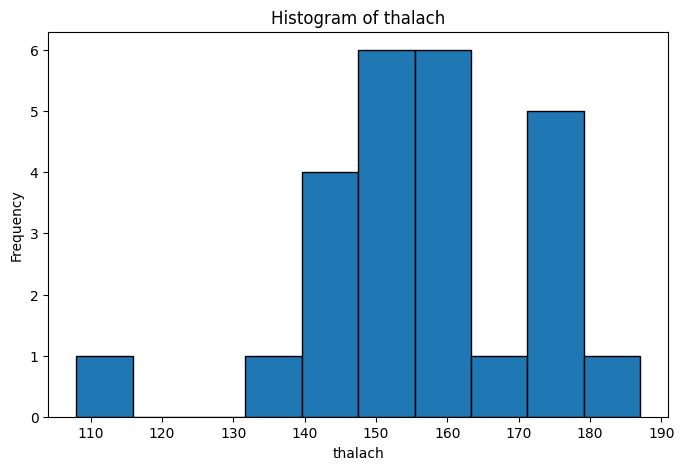

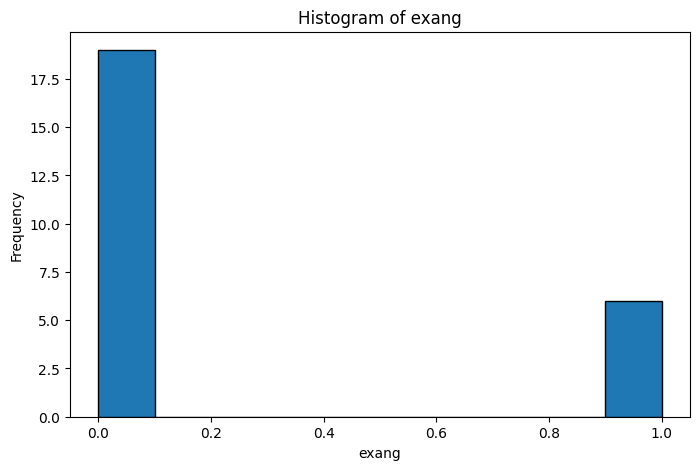

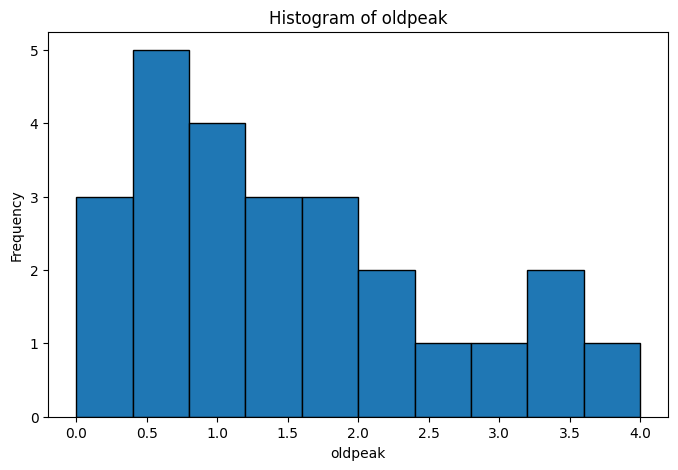

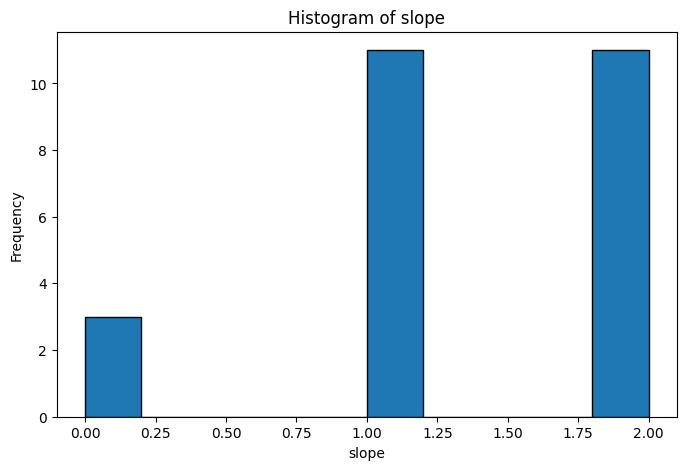

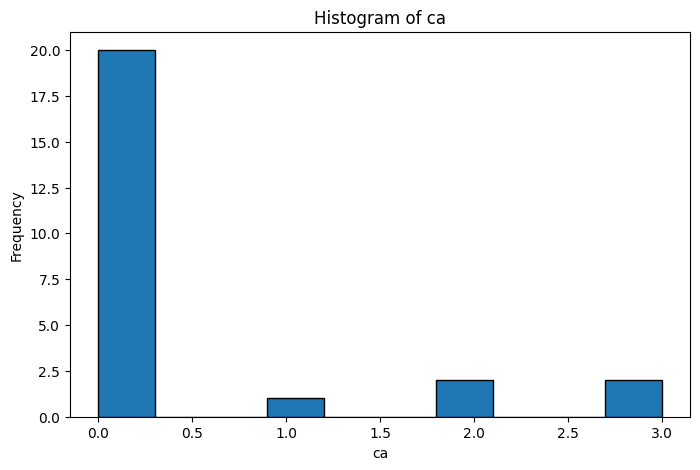

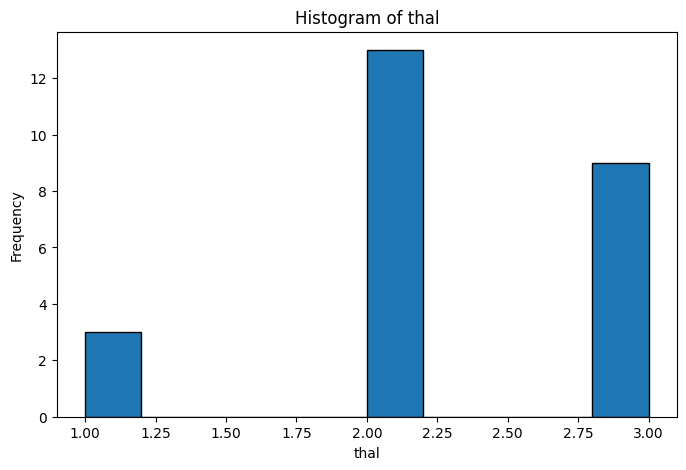

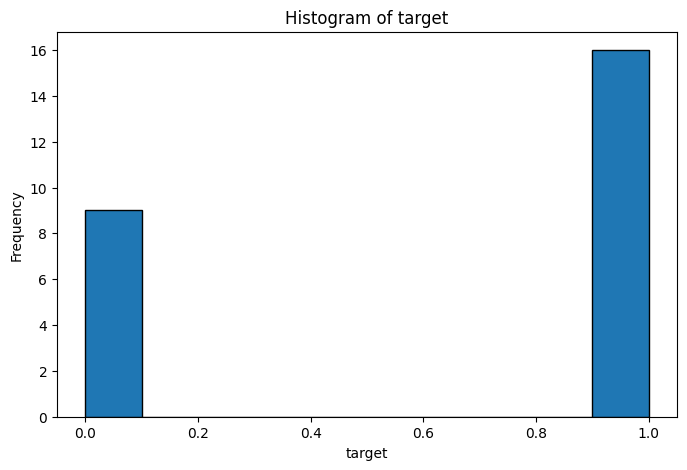

In [9]:
for column in numeric_columns:

    data = processed_df[column].dropna().values

    minimum = data.min()
    maximum = data.max()

    bins = np.linspace(minimum, maximum, 11)
    frequencies = [0] * 10

    for value in data:
        for i in range(10):
            if i == 9:
                if bins[i] <= value <= bins[i + 1]:
                    frequencies[i] += 1
            else:
                if bins[i] <= value < bins[i + 1]:
                    frequencies[i] += 1

    plt.figure(figsize=(8, 5))

    plt.bar(
        bins[:-1],
        frequencies,
        width=np.diff(bins),
        align="edge",
        edgecolor="black"
    )

    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title("Histogram of " + column)

    plt.show()

### 3)Generate box plots to identify outliers by computing quartiles, IQR, and fences manually, and visualize them using raw Matplotlib drawing functions.

In [11]:
for column in numeric_columns:

    data = processed_df[column].dropna().values

    data = np.sort(data)

    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)

    iqr = q3 - q1

    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    outliers = data[
        (data < lower_fence) |
        (data > upper_fence)
    ]

    print("\nFeature:", column)
    print("Q1:", q1)
    print("Q3:", q3)
    print("IQR:", iqr)
    print("Lower Fence:", lower_fence)
    print("Upper Fence:", upper_fence)
    print("Number of Outliers:", len(outliers))


Feature: age
Q1: 52.0
Q3: 60.0
IQR: 8.0
Lower Fence: 40.0
Upper Fence: 72.0
Number of Outliers: 1

Feature: sex
Q1: 0.0
Q3: 1.0
IQR: 1.0
Lower Fence: -1.5
Upper Fence: 2.5
Number of Outliers: 0

Feature: cp
Q1: 0.0
Q3: 2.0
IQR: 2.0
Lower Fence: -3.0
Upper Fence: 5.0
Number of Outliers: 0

Feature: trestbps
Q1: 130.0
Q3: 150.0
IQR: 20.0
Lower Fence: 100.0
Upper Fence: 180.0
Number of Outliers: 0

Feature: chol
Q1: 212.0
Q3: 266.0
IQR: 54.0
Lower Fence: 131.0
Upper Fence: 347.0
Number of Outliers: 2

Feature: fbs
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Fence: 0.0
Upper Fence: 0.0
Number of Outliers: 6

Feature: restecg
Q1: 0.0
Q3: 1.0
IQR: 1.0
Lower Fence: -1.5
Upper Fence: 2.5
Number of Outliers: 0

Feature: thalach
Q1: 148.0
Q3: 171.0
IQR: 23.0
Lower Fence: 113.5
Upper Fence: 205.5
Number of Outliers: 1

Feature: exang
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Fence: 0.0
Upper Fence: 0.0
Number of Outliers: 6

Feature: oldpeak
Q1: 0.6
Q3: 2.0
IQR: 1.4
Lower Fence: -1.4999999999999996
Upper Fence: 4.1
Num

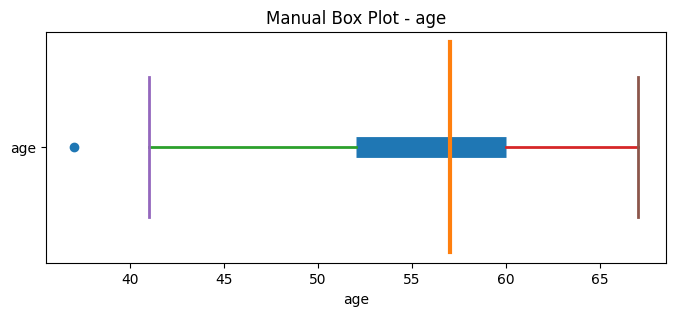

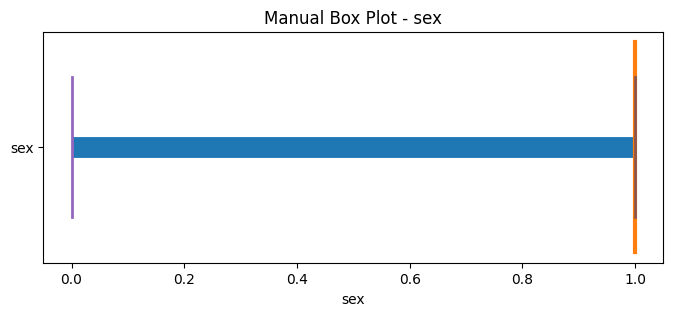

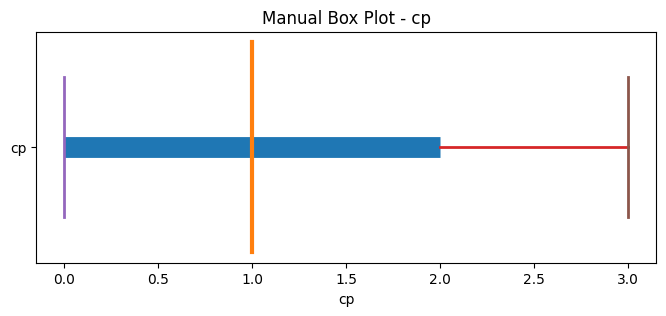

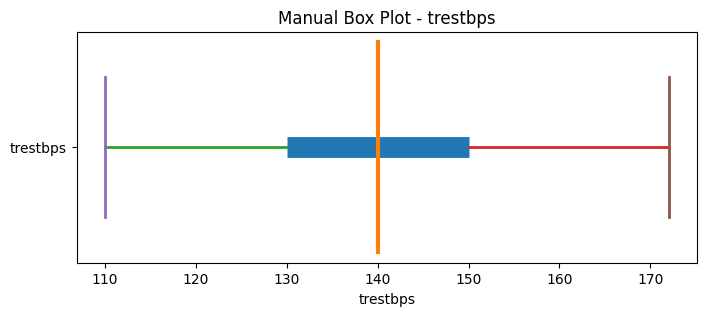

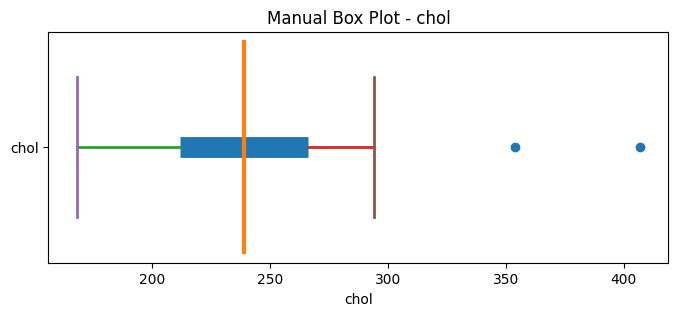

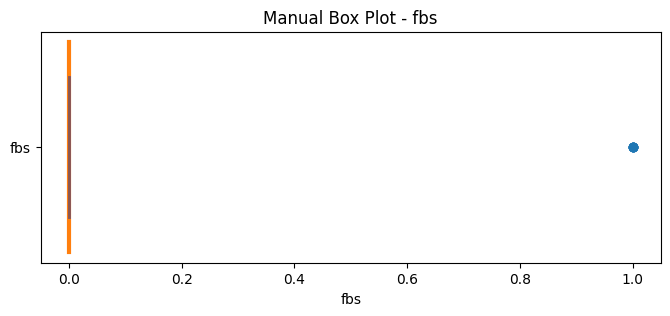

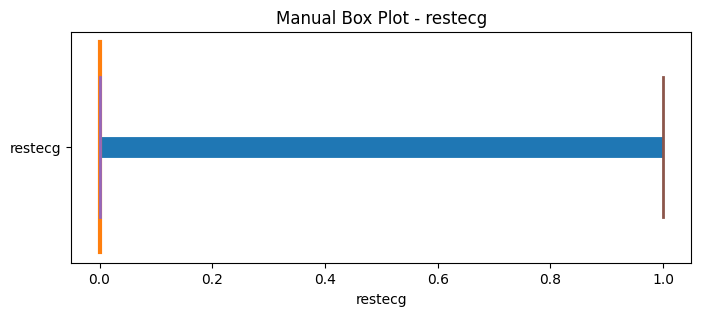

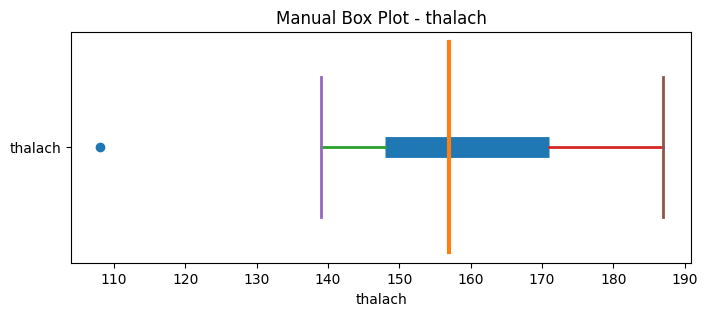

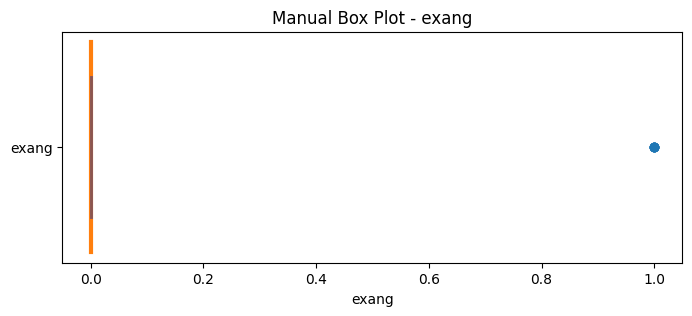

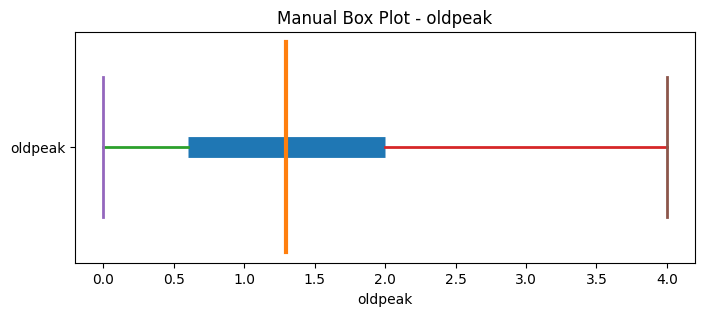

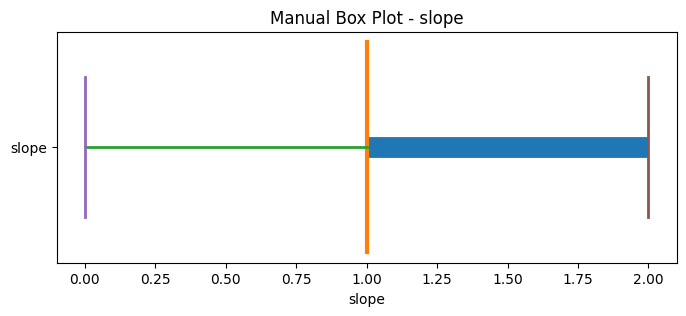

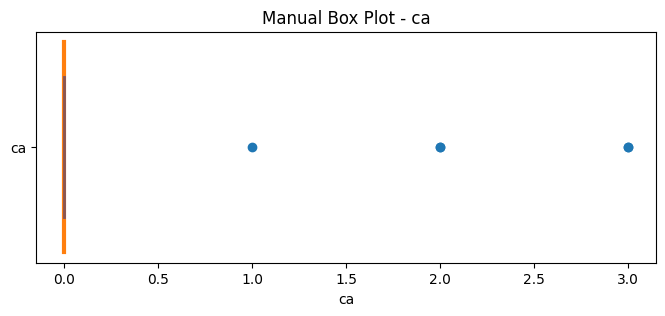

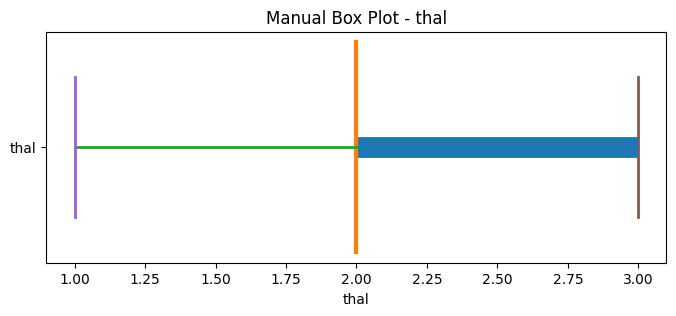

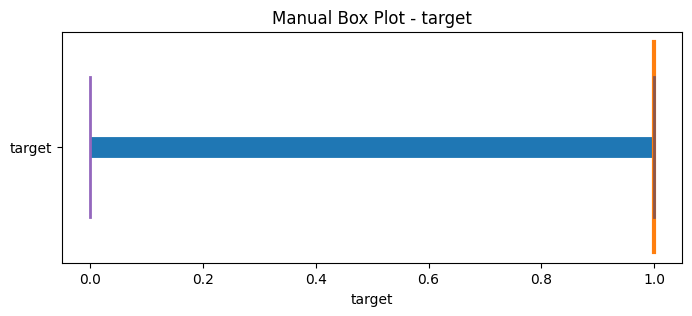

In [12]:
for column in numeric_columns:

    data = processed_df[column].dropna().values
    data = np.sort(data)

    q1 = np.percentile(data, 25)
    median = np.percentile(data, 50)
    q3 = np.percentile(data, 75)

    iqr = q3 - q1

    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    lower_whisker = data[data >= lower_fence].min()
    upper_whisker = data[data <= upper_fence].max()

    outliers = data[
        (data < lower_fence) |
        (data > upper_fence)
    ]

    plt.figure(figsize=(8, 3))

    plt.plot(
        [q1, q3],
        [1, 1],
        linewidth=15,
        solid_capstyle="butt"
    )

    plt.plot(
        [median, median],
        [0.85, 1.15],
        linewidth=3
    )

    plt.plot(
        [lower_whisker, q1],
        [1, 1],
        linewidth=2
    )

    plt.plot(
        [q3, upper_whisker],
        [1, 1],
        linewidth=2
    )

    plt.plot(
        [lower_whisker, lower_whisker],
        [0.9, 1.1],
        linewidth=2
    )

    plt.plot(
        [upper_whisker, upper_whisker],
        [0.9, 1.1],
        linewidth=2
    )

    if len(outliers) > 0:
        plt.scatter(
            outliers,
            np.ones(len(outliers)),
            marker="o"
        )

    plt.yticks([1], [column])
    plt.xlabel(column)
    plt.title("Manual Box Plot - " + column)

    plt.show()